1) Consider different values of $\omega^+$ and $\omega^-$, and calculate analytically (and plot) the result for $\vec{P(t)}$, using $\vec{P(0)}=(1,0)$.

2) Study the steady state probabilities. (what is $\lim_{t→∞}\vec{P(t)}$?)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.linalg import expm

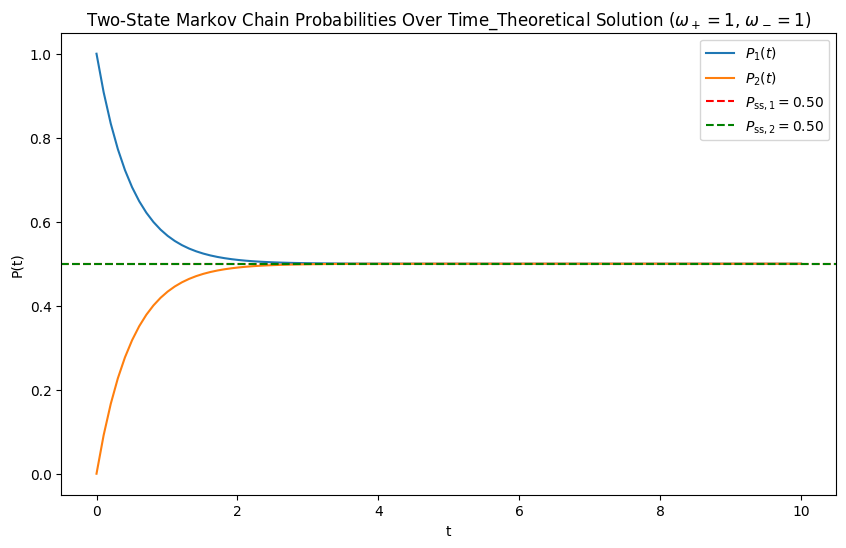

In [ ]:
def two_state_markov_chain(wp,wm, p0, t):
    """
    Solve the master equation for a two-state Markov chain using Closed form solution.
    Parameters:
    wp : float
        Transition rate from state 1 to state 2.
    wm : float
        Transition rate from state 2 to state 1.
    p0 : 1D array
        Initial state probabilities (length 2).
    t : 1D array
        Time points where the solution is computed.
    Returns:
    p_t : 2D array
        State probabilities at each time point.
    """
    Omega = wp + wm
    p_t = np.zeros((len(t), 2))

    for i, ti in enumerate(t):

        p_t[i, 0] = (wm / Omega) + (p0[0] - (wm / Omega)) * np.exp(-Omega * ti)
        p_t[i, 1] = (wp / Omega) + (p0[1] - (wp / Omega)) * np.exp(-Omega * ti)

    return p_t

def two_state_steady_state(wp, wm):
    """
    Compute the steady-state probabilities for a two-state Markov chain.
    ## Parameters:
    - wp : float
        Transition rate from state 1 to state 2.
    - wm : float
        Transition rate from state 2 to state 1.
    ## Returns:
    - p_ss : 1D array
        Steady-state probabilities (length 2).
    """
    Omega = wp + wm
    p_ss = np.array([wm / Omega, wp / Omega])

    return p_ss

def two_state_current(wp, wm, p0, t):
    """
    Compute the current of probabilities for a two-state Markov chain.
    ## Parameters:
    - wp : float
        Transition rate from state 1 to state 2.
    - wm : float
        Transition rate from state 2 to state 1.
    - p0 : 1D array
        Initial state probabilities (length 2).
    - t : 1D array
        Time points where the solution is computed.
    ## Returns:
    - J : Dict: (i, j) -> 1D array
        Current of probabilities J i<-j from state j to state i at time t.
    """
    Omega = wp + wm
    J = {}
    J[(1, 0)] = (wm - p0[0] * Omega) * np.exp(-Omega * t)
    J[(0, 1)] = (wp - p0[1] * Omega) * np.exp(-Omega * t)

    return J
# Example usage
wp = 1  # Transition rate from state 1 to state 2
wm = 1  # Transition rate from state 2 to state 1
p0 = np.array([1, 0])  # Initial state
t = np.linspace(0, 10, 100)
p_t_two_state = two_state_markov_chain(wp, wm, p0, t)
p_ss = two_state_steady_state(wp, wm)
# Plotting the results
plt.figure(figsize=(10, 6))
for i in range(p_t_two_state.shape[1]):
    plt.plot(t, p_t_two_state[:, i], label=fr'$P_{{{i+1}}}(t)$')
plt.axhline(y=p_ss[0], color='r', linestyle='--', label=fr'$P_{{\mathrm{{ss}},1}} = {p_ss[0]:.2f}$')
plt.axhline(y=p_ss[1], color='g', linestyle='--', label=fr'$P_{{\mathrm{{ss}},2}} = {p_ss[1]:.2f}$')
plt.xlabel('t')
plt.ylabel('P(t)')
plt.title(rf'Two-State Markov Chain Probabilities Over Time_Theoretical Solution 'rf'($\omega_+ = {wp}$, $\omega_- = {wm}$)')
plt.legend()
plt.show()

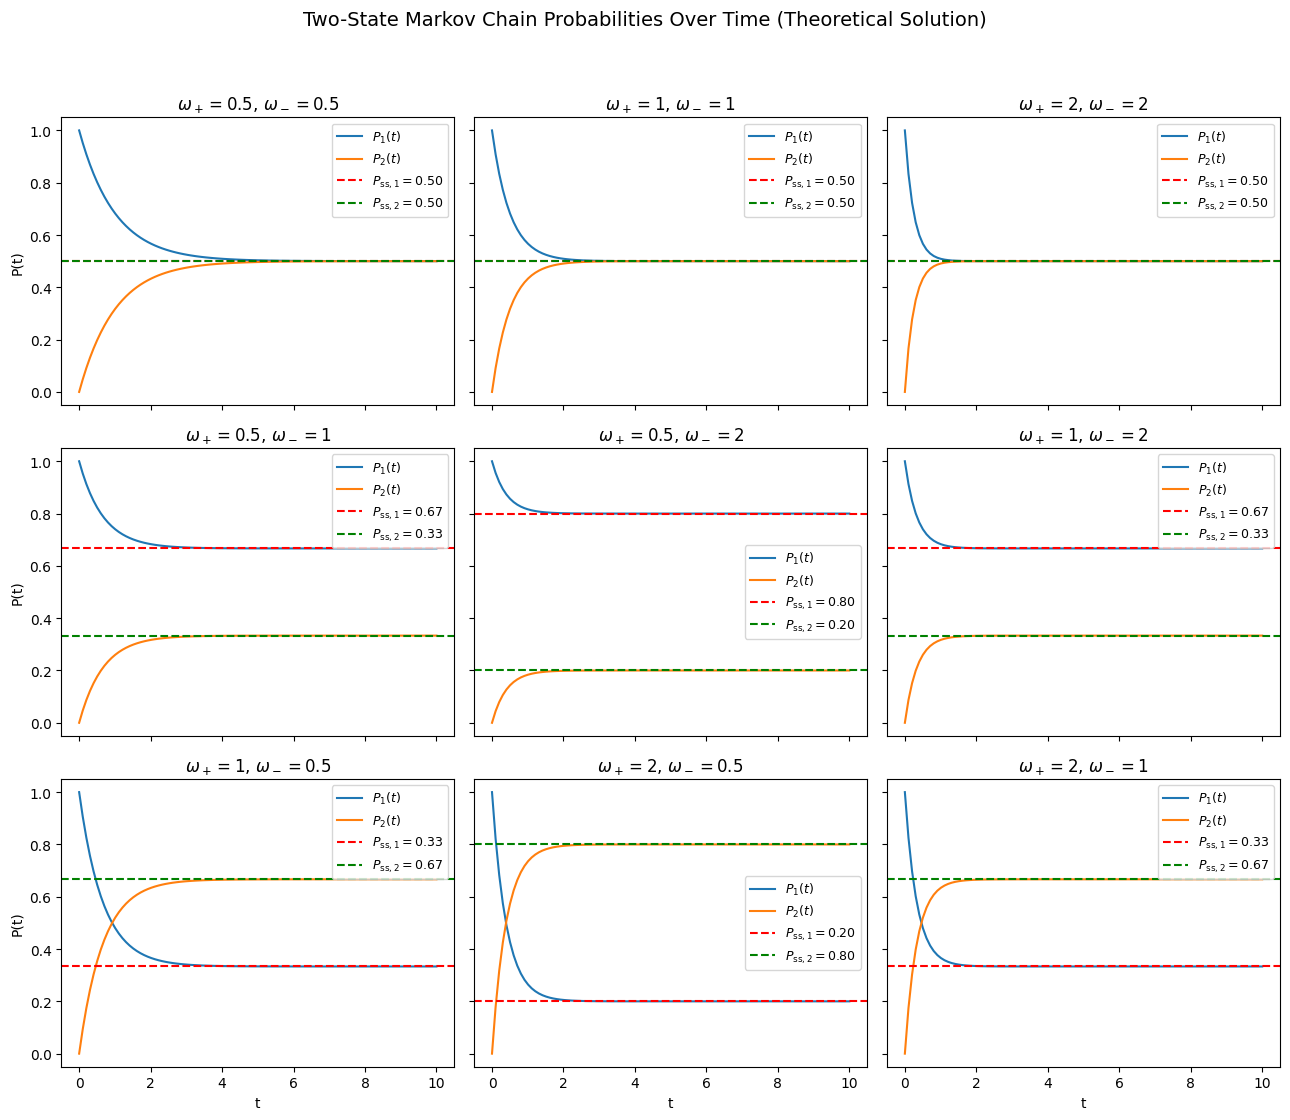

In [ ]:
def two_state_markov_chain(wp,wm, p0, t):
    """
    Solve the master equation for a two-state Markov chain using Closed form solution.
    Parameters:
    wp : float
        Transition rate from state 1 to state 2.
    wm : float
        Transition rate from state 2 to state 1.
    p0 : 1D array
        Initial state probabilities (length 2).
    t : 1D array
        Time points where the solution is computed.
    Returns:
    p_t : 2D array
        State probabilities at each time point.
    """
    Omega = wp + wm
    p_t = np.zeros((len(t), 2))

    for i, ti in enumerate(t):

        p_t[i, 0] = (wm / Omega) + (p0[0] - (wm / Omega)) * np.exp(-Omega * ti)
        p_t[i, 1] = (wp / Omega) + (p0[1] - (wp / Omega)) * np.exp(-Omega * ti)

    return p_t

def two_state_steady_state(wp, wm):
    """
    Compute the steady-state probabilities for a two-state Markov chain.
    ## Parameters:
    - wp : float
        Transition rate from state 1 to state 2.
    - wm : float
        Transition rate from state 2 to state 1.
    ## Returns:
    - p_ss : 1D array
        Steady-state probabilities (length 2).
    """
    Omega = wp + wm
    p_ss = np.array([wm / Omega, wp / Omega])

    return p_ss

def two_state_current(wp, wm, p0, t):
    """
    Compute the current of probabilities for a two-state Markov chain.
    ## Parameters:
    - wp : float
        Transition rate from state 1 to state 2.
    - wm : float
        Transition rate from state 2 to state 1.
    - p0 : 1D array
        Initial state probabilities (length 2).
    - t : 1D array
        Time points where the solution is computed.
    ## Returns:
    - J : Dict: (i, j) -> 1D array
        Current of probabilities J i<-j from state j to state i at time t.
    """
    Omega = wp + wm
    J = {}
    J[(1, 0)] = (wm - p0[0] * Omega) * np.exp(-Omega * t)
    J[(0, 1)] = (wp - p0[1] * Omega) * np.exp(-Omega * t)

    return J
# Example usage
wp_list = [0.5, 1, 2]  # Transition rate from state 1 to state 2
wm_list = [0.5, 1, 2]  # Transition rate from state 2 to state 1
p0 = np.array([1, 0])  # Initial state
t = np.linspace(0, 10, 100)

equal_rates = []
wp_greater = []
wm_greater = []

for wp in wp_list:
    for wm in wm_list:
        if wp == wm:
            equal_rates.append((wp, wm))
        elif wp > wm:
            wp_greater.append((wp, wm))
        else:
            wm_greater.append((wp, wm))

all_cases = [equal_rates, wm_greater, wp_greater]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(13, 12), sharex=True, sharey=True)

for row, group in enumerate(all_cases):
    for col in range(3):
        ax = axes[row, col]
        if col < len(group):
            wp, wm = group[col]
            p_t_two_state = two_state_markov_chain(wp, wm, p0, t)
            p_ss = two_state_steady_state(wp, wm)

            for k in range(p_t_two_state.shape[1]):
                ax.plot(t, p_t_two_state[:, k], label=fr'$P_{{{k+1}}}(t)$')
            ax.axhline(y=p_ss[0], color='r', linestyle='--', label=fr'$P_{{\mathrm{{ss}},1}} = {p_ss[0]:.2f}$')
            ax.axhline(y=p_ss[1], color='g', linestyle='--', label=fr'$P_{{\mathrm{{ss}},2}} = {p_ss[1]:.2f}$')
            ax.set_title(rf'$\omega_+ = {wp}$, $\omega_- = {wm}$')
            ax.legend(fontsize=9)
            ax.grid(False)
        else:
            ax.axis('off')


for ax in axes[2, :]:
    ax.set_xlabel('t')
for ax in axes[:, 0]:
    ax.set_ylabel('P(t)')

fig.suptitle('Two-State Markov Chain Probabilities Over Time (Theoretical Solution)', fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


3) Construct a function that generates a stochastic trajectory of jumping times up to a maximum time $T$.

In [ ]:
### Gillespie algorithm for trajectories

def get_next_n(n_current):
    n_current = int(n_current)
    for n in [1,2]:
        if n != n_current:
           return n

def get_next_tau(n_current, omega_plus, omega_minus):

  # Sample u from a uniform distribution
  u = np.random.uniform(0, 1, size=1)[0]

  # Transform u to an exponentially distributed r.v.
  tau_plus = np.log(1/u)/omega_plus
  tau_minus = np.log(1/u)/omega_minus

  if n_current == 1:
    tau_next = tau_plus

  elif n_current == 2:
    tau_next = tau_minus

  return tau_next

def get_trajectory(t_max, omega_plus, omega_minus, n_0=1):

  '''
  ### Inputs
    1. $t_{max}$ — maximum simulation time
    2. $\omega_{+}$ — rate of transition $1 to 2$
    3. $\omega_{-}$ — rate of transition $2 to 1$
    4. $n_{0}$ — initial state ($1$ or $2$)

---

### Outputs
  - $t$ — array of sampling times plus final $t_{max}$
  - $n$ — array of states at each sampling time
  - $\tau$ — array of exponentially distributed waiting times between jumps
    (final residual interval not included)

  '''

  # initialize list of timepoints and waiting times; set t_0 = 0
  t = []
  t.append(0)
  tau = []

  # initialize list of positions
  n = []
  n.append(n_0)

  while t[-1] < t_max:

    # get next timepoint
    tau.append(get_next_tau(n[-1], omega_plus, omega_minus))

    if t[-1] + tau[-1] > t_max:
      break

    else:
      t.append(t[-1] + tau[-1])

    # get next position
    n.append(get_next_n(n[-1]))

  # set final (t, n)
  t.append(t_max)
  n.append(n[-1])

  return np.array(t),np.array(n),np.array(tau)

<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipython-input-22452557.py:31: SyntaxWarning: invalid escape sequence '\o'
  2. $\omega_{+}$ — rate of transition $1 to 2$


- Plotting Trajectory

Sample trajectory:  [1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 2]


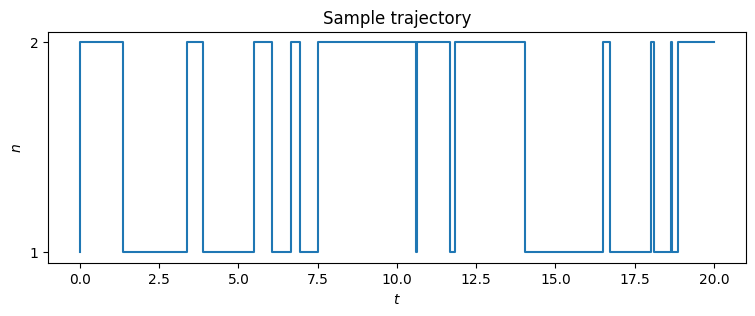

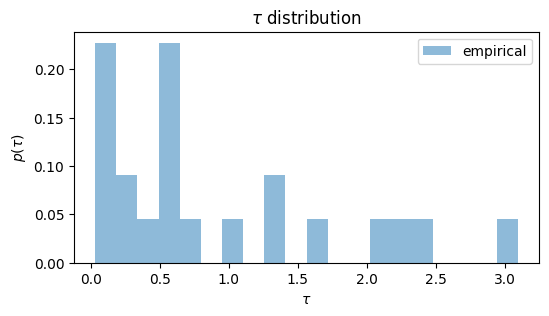

In [ ]:
# Test
t_max=20
omega_plus=1
omega_minus=1
n_0=1

t, n, tau = get_trajectory(t_max, omega_plus, omega_minus, n_0)

# Sample trajectory
print('Sample trajectory: ', n)
plt.figure(figsize=(9,3))
plt.step(t,n)
plt.xlabel('$t$')
plt.ylabel('$n$')
plt.yticks([1,2])
plt.title('Sample trajectory')
plt.show()


# Distribution of waiting times
x = np.linspace(0,1,1000)
y = (1/omega_plus)*np.exp(-omega_plus*x)

counts, bin_edges = np.histogram(tau, bins=20, density=True)
counts = counts/np.sum(counts)
bin_centers = 0.5*(bin_edges[1:]+bin_edges[:-1])
plt.figure(figsize=(6,3))
plt.bar(bin_centers, counts,
        width=bin_edges[1] - bin_edges[0],
        align='center', alpha=0.5, label='empirical')
plt.xlabel(f'$\\tau$')
plt.ylabel(f'$p(\\tau)$')
plt.title('$\\tau$ distribution')
plt.legend()
plt.show()

4) Generate a large number of trajectories, and for a selection of times between $0$ and $T$ compare the empirical probability $P_1^{empirical}(t)$ with the analytical prediction $P_1(t)$.

In [ ]:
# Function for resampling trajectory data
def resample_trajectory(key, dict_trajectories, t_max, dt):

  t_old = dict_trajectories[key]['time']
  n_old = dict_trajectories[key]['position']

  # initialize new array of sampling times and positions
  t_new = np.arange(0, t_max+dt, dt)
  N = len(t_new)
  n_new = np.ones(N)

  for idx_new, t in enumerate(t_new):
    idx_old = np.searchsorted(t_old, t, side='right') - 1
    idx_old = max(idx_old, 0)
    n_new[idx_new] = n_old[idx_old]

  return t_new, n_new, key


# Parameters
N_traj = int(1e3)                       # no. of trajectories/simulations
t_max = 10                              # maximum time, T
omega_plus_list = [0.5, 1, 2]           # list of omega_+ values
omega_minus_list = [0.5, 1, 2]          # list of omega_- values
n_0 = 1                                 # initial position
dt = t_max/1000                         # fixed time interval

# Initialize dict for storing trajectories and waiting times
trajectories = {}

# Generate 1000 trajectories for each (omega_+, omega_-)
for omega_plus in omega_plus_list:
  for omega_minus in omega_minus_list:
    for i in range(N_traj):
      t, n, tau = get_trajectory(t_max, omega_plus, omega_minus, n_0)
      trajectories[f"w+{omega_plus}_w-{omega_minus}_r{i}"] = {"time" : t, "position" : n, "waiting time": tau}

keys = trajectories.keys()
# Resample trajectories, modify dictionary of trajectory data.
for key in list(keys):
  t_new, n_new, key = resample_trajectory(key, trajectories, t_max, dt)
  trajectories[key]['time'] = t_new
  trajectories[key]['position'] = n_new

- Calculating Empirical Probability $P_1^{empirical}(t)$:

In [ ]:
import numpy as np
import re

# The time axis is the same for all resampled trajectories,
# so we will store it once when we encounter the first trajectory.
t_axis = None

# Dictionaries to store:
# - counts[(w_plus, w_minus)] → number of trajectories in state n=1 at each time
# - totals[(w_plus, w_minus)] → total number of trajectories for that parameter pair
counts = {}
totals = {}

# Regex pattern to extract omega_plus and omega_minus from trajectory key names
pattern = re.compile(r"w\+([0-9.]+)_w-([0-9.]+)_r\d+")

# Loop over all trajectories
for key, data in trajectories.items():

    # Get the time axis (same for all trajectories)
    if t_axis is None:
        t_axis = data['time']

    # Extract omega_plus and omega_minus from the key name
    match = pattern.match(key)
    if match is None:
        raise ValueError(f"Key format not recognized: {key}")

    w_plus, w_minus = map(float, match.groups())
    pair = (w_plus, w_minus)

    # Initialize counters for this parameter pair if not already present
    if pair not in counts:
        counts[pair] = np.zeros_like(t_axis, dtype=np.int32)
        totals[pair] = 0

    # Increment the count where n=1 for this trajectory
    counts[pair] += (data['position'] == 1).astype(np.int32)

    # Increment total number of trajectories for this (w_plus, w_minus)
    totals[pair] += 1

# Compute probability P1(t) = (# of trajectories with n=1) / (total # of trajectories)
P1_Empirical = {pair: counts[pair] / totals[pair] for pair in counts}

print(P1_Empirical.keys())


dict_keys([(0.5, 0.5), (0.5, 1.0), (0.5, 2.0), (1.0, 0.5), (1.0, 1.0), (1.0, 2.0), (2.0, 0.5), (2.0, 1.0), (2.0, 2.0)])


- Comparing the empirical probability $P_1^{empirical}(t)$ with the analytical prediction $P_1(t)$:

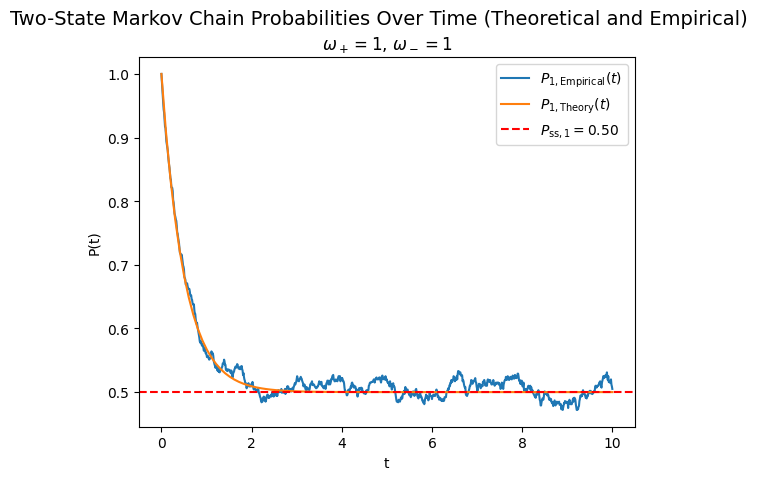

In [ ]:
wp = 1  # Transition rate from state 1 to state 2
wm = 1  # Transition rate from state 2 to state 1
p0 = np.array([1, 0])  # Initial state
t = np.linspace(0, 10, 100)

p_t_two_state = two_state_markov_chain(wp, wm, p0, t)
p_ss = two_state_steady_state(wp, wm)

plt.plot(t_axis, P1_Empirical[(wp, wm)], label=fr'$P_{{1, \mathrm{{Empirical}}}}(t)$')
plt.plot(t, p_t_two_state[:, 0], label=fr'$P_{{1, \mathrm{{Theory}}}}(t)$')
plt.axhline(y=p_ss[0], color='r', linestyle='--', label=fr'$P_{{\mathrm{{ss}},1}} = {p_ss[0]:.2f}$')
plt.title(rf'$\omega_+ = {wp}$, $\omega_- = {wm}$')
plt.legend(fontsize=10)
plt.grid(False)
plt.xlabel('t')
plt.ylabel('P(t)')

plt.suptitle('Two-State Markov Chain Probabilities Over Time (Theoretical and Empirical)', fontsize=14)
plt.show()

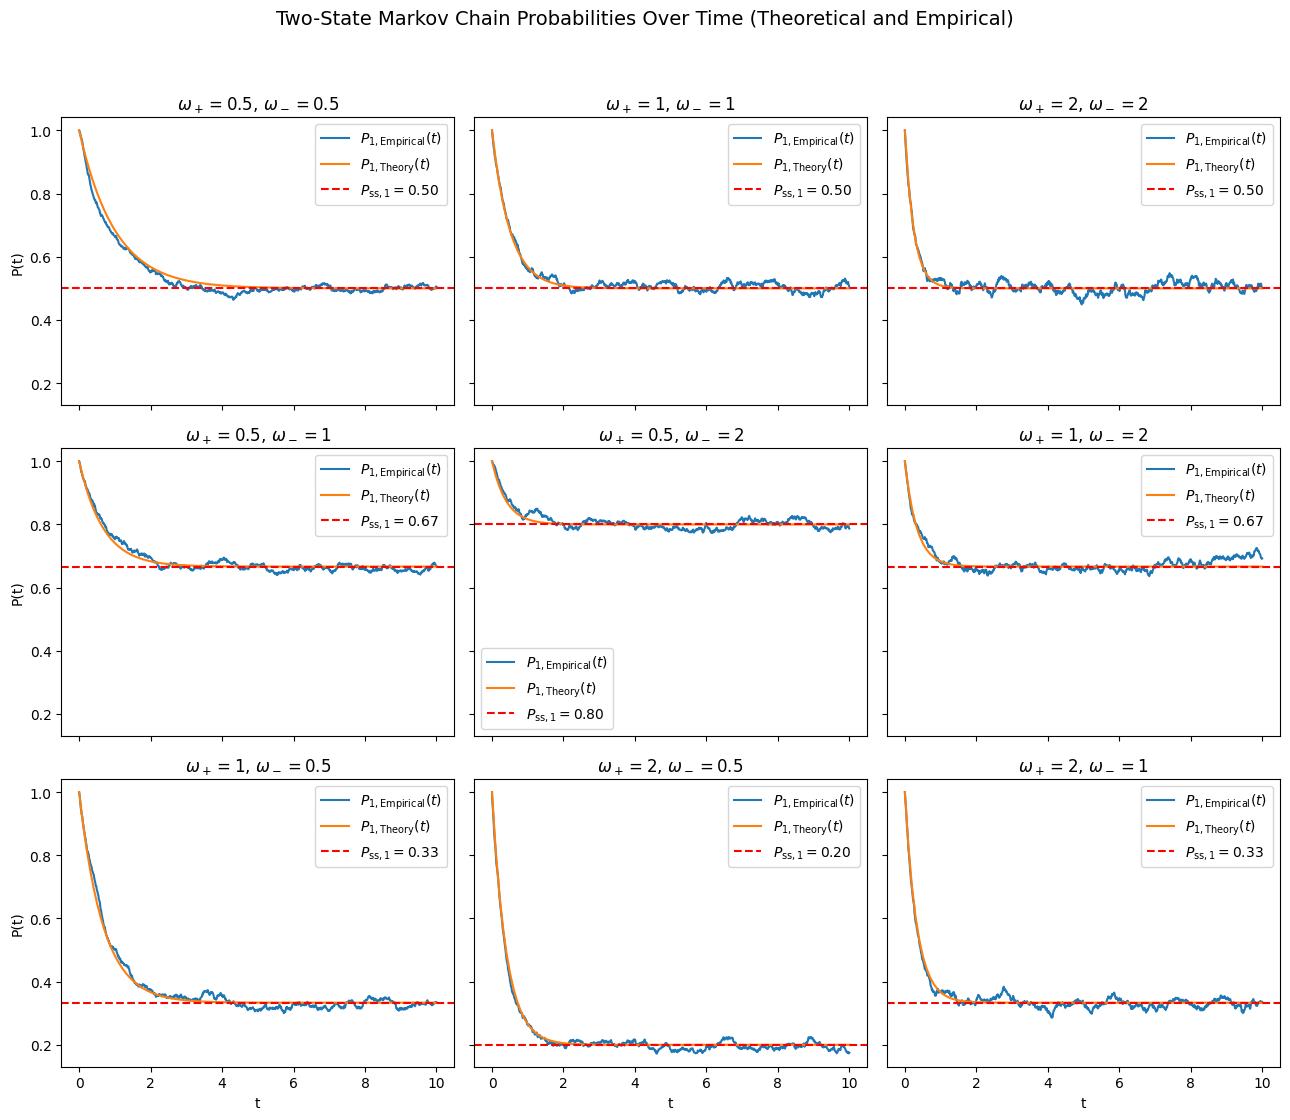

In [ ]:
wp_list = [0.5, 1, 2]  # Transition rate from state 1 to state 2
wm_list = [0.5, 1, 2]  # Transition rate from state 2 to state 1
p0 = np.array([1, 0])  # Initial state
t = np.linspace(0, 10, 100)

equal_rates = []
wp_greater = []
wm_greater = []

for wp in wp_list:
    for wm in wm_list:
        if wp == wm:
            equal_rates.append((wp, wm))
        elif wp > wm:
            wp_greater.append((wp, wm))
        else:
            wm_greater.append((wp, wm))

all_cases = [equal_rates, wm_greater, wp_greater]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(13, 12), sharex=True, sharey=True)

for row, group in enumerate(all_cases):
    for col in range(3):
        ax = axes[row, col]
        if col < len(group):
            wp, wm = group[col]
            p_t_two_state = two_state_markov_chain(wp, wm, p0, t)
            p_ss = two_state_steady_state(wp, wm)

            ax.plot(t_axis, P1_Empirical[(wp, wm)], label=fr'$P_{{1, \mathrm{{Empirical}}}}(t)$')
            ax.plot(t, p_t_two_state[:, 0], label=fr'$P_{{1, \mathrm{{Theory}}}}(t)$')
            ax.axhline(y=p_ss[0], color='r', linestyle='--', label=fr'$P_{{\mathrm{{ss}},1}} = {p_ss[0]:.2f}$')
            ax.set_title(rf'$\omega_+ = {wp}$, $\omega_- = {wm}$')
            ax.legend(fontsize=10)
            ax.grid(False)
        else:
            ax.axis('off')


for ax in axes[2, :]:
    ax.set_xlabel('t')
for ax in axes[:, 0]:
    ax.set_ylabel('P(t)')

fig.suptitle('Two-State Markov Chain Probabilities Over Time (Theoretical and Empirical)', fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


5) Calculate the instantaneous average current between the two states. You should start away from the stationary states, which should reach zero at long times.

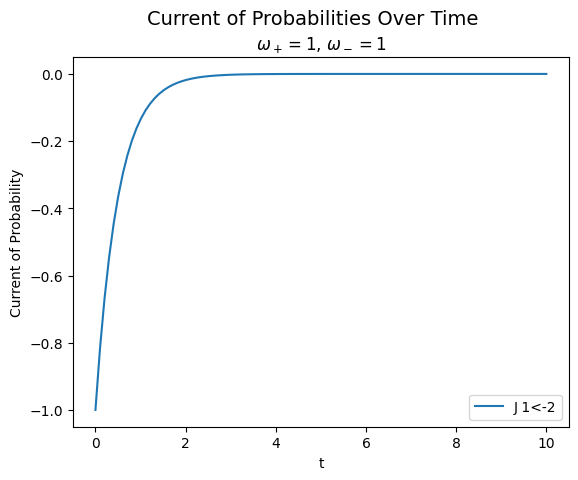

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm  # Importing the expm function

def exponential_Markov(L, p0, t):
    """
    Solve the master equation dp/dt = L * p for a Markov chain using matrix exponentiation.

    Parameters:
    L : 2D array
        Generator matrix.
    p0 : 1D array
        Initial state probabilities.
    t : 1D array
        Time points where the solution is computed.

    Returns:
    p_t : 2D array
        State probabilities at each time point.
    """
    p_t = np.array([expm(L * ti) @ p0 for ti in t])
    return p_t

def current_probabilities(L, p0, t):
    """
    Calculate the current of probabilities in a Markov chain with n states.

    Parameters:
    - L : 2D array
        Transition rate matrix (size n x n).
    - p0 : 1D array
        Initial probabilities (length n).
    - t : 1D array
        Time at which to evaluate the current.

    Returns:
    - current : Dict: (i, j) -> 1D array
        Current of probabilities J i<-j from state j to state i at time t.
    """
    p_t = exponential_Markov(L, p0, t)

    current = {}

    # For each pair of states (i, j) calculate the current
    for i in range(len(p0)):
        for j in range(i + 1, len(p0)):  # Only for j > i to avoid duplicates
            current[(i, j)] = L[i, j] * p_t[:, j] - L[j, i] * p_t[:, i]

    return current

# Parameters
wp = 1  # Transition rate from state 1 to state 2
wm = 1  # Transition rate from state 2 to state 1
p0 = np.array([1, 0])  # Initial state (state 1)
t = np.linspace(0, 10, 100)  # Time array

L = np.array([[-wp, wm], [wp, -wm]])  # Transition rate matrix
current = current_probabilities(L, p0, t)  # Get current probabilities

# Plot the currents for each pair (i, j)
for (i, j), J in current.items():
    plt.plot(t, J, label=f'J {i+1}<-{j+1}')

plt.title(rf'$\omega_+ = {wp}$, $\omega_- = {wm}$')
plt.legend(fontsize=10)
plt.grid(False)
plt.xlabel('t')
plt.ylabel('Current of Probability')

plt.suptitle('Current of Probabilities Over Time', fontsize=14)
plt.show()

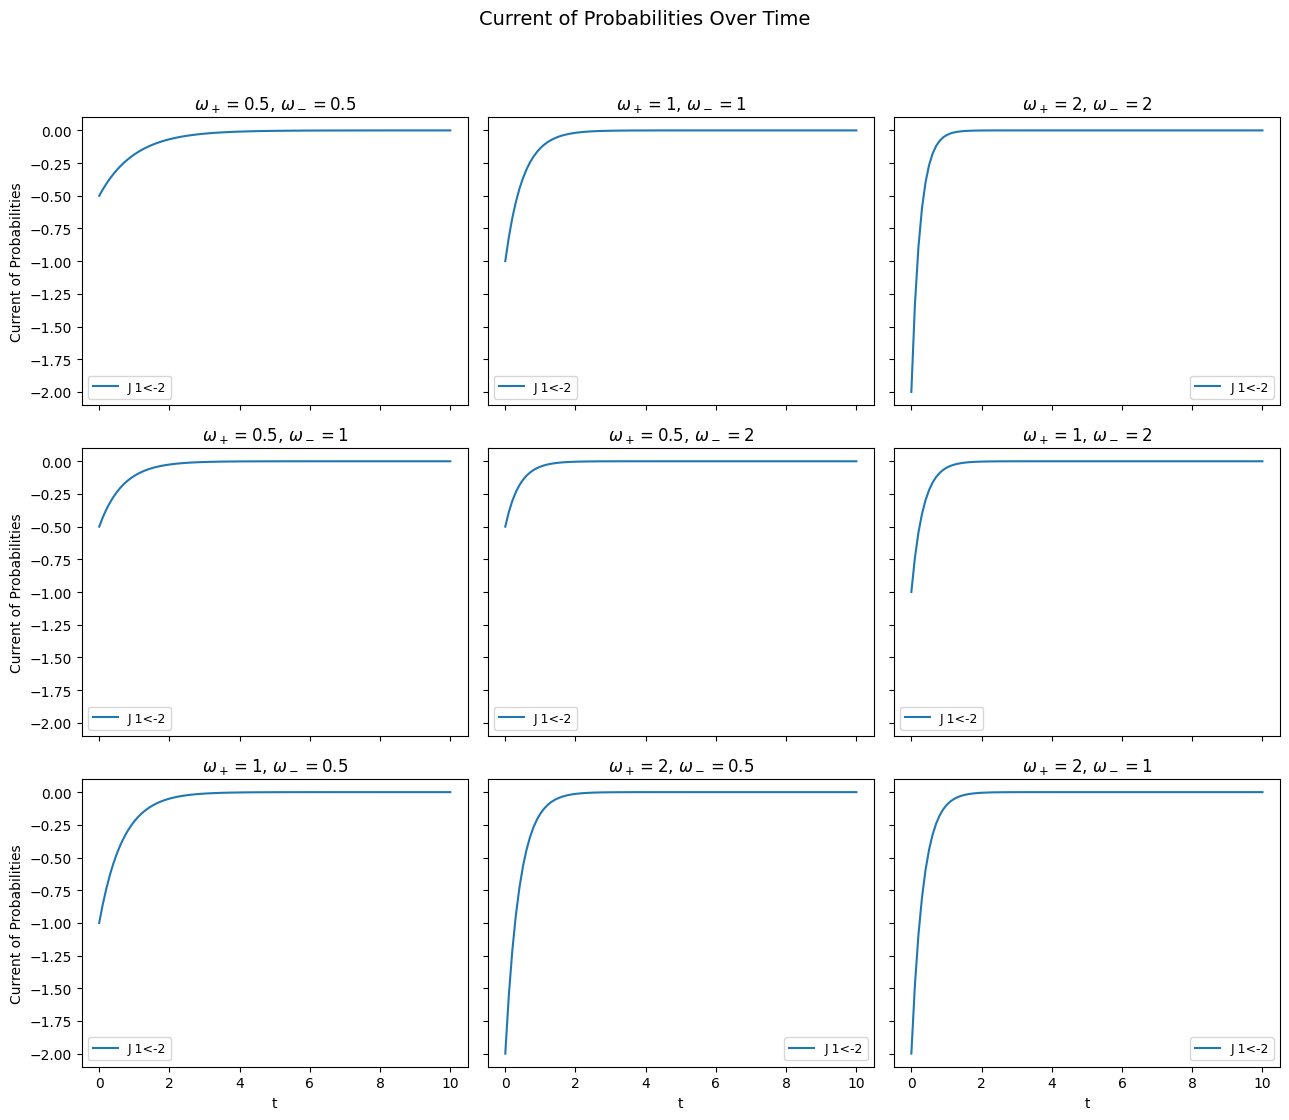

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm  # Importing the expm function

def exponential_Markov(L, p0, t):
    """
    Solve the master equation dp/dt = L * p for a Markov chain using matrix exponentiation.

    Parameters:
    L : 2D array
        Generator matrix.
    p0 : 1D array
        Initial state probabilities.
    t : 1D array
        Time points where the solution is computed.

    Returns:
    p_t : 2D array
        State probabilities at each time point.
    """
    p_t = np.array([expm(L * ti) @ p0 for ti in t])
    return p_t

def current_probabilities(L, p0, t):
    """
    Calculate the current of probabilities in a Markov chain with n states.

    Parameters:
    - L : 2D array
        Transition rate matrix (size n x n).
    - p0 : 1D array
        Initial probabilities (length n).
    - t : 1D array
        Time at which to evaluate the current.

    Returns:
    - current : Dict: (i, j) -> 1D array
        Current of probabilities J i<-j from state j to state i at time t.
    """
    p_t = exponential_Markov(L, p0, t)

    current = {}

    # For each pair of states (i, j) calculate the current
    for i in range(len(p0)):
        for j in range(i + 1, len(p0)):  # Only for j > i to avoid duplicates
            current[(i, j)] = L[i, j] * p_t[:, j] - L[j, i] * p_t[:, i]

    return current

# Parameters
wp_list = [0.5, 1, 2]  # Transition rate from state 1 to state 2
wm_list = [0.5, 1, 2]  # Transition rate from state 2 to state 1
p0 = np.array([1, 0])  # Initial state (state 1)
t = np.linspace(0, 10, 100)  # Time array

# Categorize the different rate combinations
equal_rates = []
wp_greater = []
wm_greater = []

for wp in wp_list:
    for wm in wm_list:
        if wp == wm:
            equal_rates.append((wp, wm))
        elif wp > wm:
            wp_greater.append((wp, wm))
        else:
            wm_greater.append((wp, wm))

all_cases = [equal_rates, wm_greater, wp_greater]

# Plotting
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(13, 12), sharex=True, sharey=True)

# Loop through cases and plot current probabilities
for row, group in enumerate(all_cases):
    for col in range(3):
        ax = axes[row, col]
        if col < len(group):
            wp, wm = group[col]
            L = np.array([[-wp, wm], [wp, -wm]])  # Transition rate matrix
            current = current_probabilities(L, p0, t)  # Get current probabilities

            # Plot the currents for each pair (i, j)
            for (i, j), J in current.items():
                ax.plot(t, J, label=f'J {i+1}<-{j+1}')

            ax.set_title(rf'$\omega_+ = {wp}$, $\omega_- = {wm}$')
            ax.legend(fontsize=9)
            ax.grid(False)
        else:
            ax.axis('off')

# Label the axes
for ax in axes[2, :]:
    ax.set_xlabel('t')
for ax in axes[:, 0]:
    ax.set_ylabel('Current of Probabilities')

# Overall title
fig.suptitle('Current of Probabilities Over Time', fontsize=14)

# Adjust layout and show the plot
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()